# DriftMind Cold-Start Forecasting Demo

This notebook shows how to:

1. Load DriftMind credentials from a `.env` file.
2. Create a `DriftMindClient` and a new forecaster.
3. Generate synthetic sinusoidal data with drifts.
4. Feed data online and request forecasts (tracking SME metrics online).
5. Visualize actual vs predicted values and global anomaly signals.
6. Visualize global statistics evolution
7. Check data exisiting in the server for forecaster created  
8. List all the Forecasters available in the Server

In [1]:
from __future__ import annotations

import pandas as pd
import sys
import os


sys.path.append(os.path.abspath("../src"))

from driftmind import DriftMindClient, DriftMindConfigError, DriftMindError
from driftmind.generator import generate_sin_cos_tan_with_drifts
from driftmind.utils import (
    load_credentials,
    plot_actual_vs_predicted,
    plot_time_series,
)

In [2]:
def show_forecaster_details(client: DriftMindClient, forecaster_id: str) -> None:
    """Call the API and pretty-print forecaster details."""
    try:
        details = client.get_forecaster_details(forecaster_id)
    except DriftMindError as err:
        print(f"❌ Failed to fetch forecaster details: {err}")
        return

    if not details:
        print("❌ No details available")
        return

    print("\n=== Forecaster Details ===")
    print(f"ID: {details.get('forecasterId', '-')}")
    print(f"Name: {details.get('forecasterName', '-')}")

    # Features
    features = details.get("features", [])
    print(f"Features: {', '.join(features) if features else '-'}")

    # Properties (note: key was 'properities' previously; adjust to actual API)
    props = details.get("configuration", {}) or details.get("configuration", {})
    if props:
        print("\n--- Properties ---")
        for key, value in props.items():
            print(f"{key}: {value}")
    else:
        print("No configuration available")


def show_forecaster_data(client: DriftMindClient, forecaster_id: str) -> None:
    """Call the API and pretty-print all data currently held by a forecaster."""
    try:
        data = client.get_forecaster_data(forecaster_id)
    except DriftMindError as err:
        print(f"❌ Failed to fetch forecaster data: {err}")
        return

    if not data or "data" not in data:
        print("❌ No data available for this forecaster")
        return

    print(f"\n=== Forecaster Data (total {len(data['data'])} points) ===")

    for ts, values in data["data"].items():
        features = ", ".join(f"{k}={v}" for k, v in values.items())
        print(f"{ts} → {features}")

## 1. Load DriftMind credentials from a '.env' file

Credentials are expected as:

- `DRIFTMIND_API_KEY`
- `DRIFTMIND_API_URL`

In [3]:
try:
    from pathlib import Path
    env_path = Path("..") / "env" / ".env"
    creds = load_credentials(str(env_path))
    api_key = creds["DRIFTMIND_API_KEY"]
    base_url = creds["DRIFTMIND_API_URL"]
    print("✅ Credentials loaded. Target URL:", base_url)
except DriftMindConfigError as err:
    raise RuntimeError(
        "Failed to load DriftMind credentials. "
        "Ensure DRIFTMIND_API_KEY and DRIFTMIND_API_URL are set in "
        "your environment or .env file."
    ) from err

client = DriftMindClient(api_key=api_key, base_url=base_url)


✅ Credentials loaded. Target URL: https://api.thingbook.io/access/api/driftmind/v1/


## 2. Create a new forecaster

We create a fresh forecaster for this demo run.

In [4]:
columns = ["sin", "cos", "tan"]

forecaster_payload = {
    "forecasterName": "Cold Start Demo",
    "features": columns,
    "inputSize": 15,
    "outputSize": 1,
    "maxClustersAllowed": 100,
    "timeStampIntervalInSeconds": 30,
}

try:
    forecaster_info = client.create_forecaster(forecaster_payload)
except DriftMindError as err:
    raise RuntimeError("Failed to create forecaster.") from err

# Adjust ID extraction to actual API response shape.
forecaster_id = (
    forecaster_info.get("forecaster_id")
    or forecaster_info.get("forecasterId")
    or forecaster_info.get("id")
)

if not forecaster_id:
    raise RuntimeError("Could not determine forecaster ID from response.")

print(f"Created new forecaster with ID: {forecaster_id}")

show_forecaster_details(client, forecaster_id)

TARGETING URL 1: POST https://api.thingbook.io/access/api/driftmind/v1/forecasters
Created new forecaster with ID: 8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e
TARGETING URL 1: GET https://api.thingbook.io/access/api/driftmind/v1/forecasters/8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e

=== Forecaster Details ===
ID: 8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e
Name: Cold Start Demo
Features: tan, sin, cos

--- Properties ---
fitRate: 1
initializationDate: 08-01-2026 14:46:16
maxClustersAllowed: 100
dateFormat: dd-MM-yyyy HH:mm:ss
similarityThreshold: 0.8
timeStampIntervalInSeconds: 30
outputSize: 1
inputSize: 15


## 3. Generate synthetic dataset with drifts

We now generate a dataset with sinusoidal drifts using a helper from `driftmind.generator`.

It creates a pandas DataFrame with columns:
- ``sequence``: Integer time index from 0 to n-1.
- ``sin``: Sine component with drifts.
- ``cos``: Cosine component with drifts.
- ``tan``: Clipped tangent component with drifts.

In [5]:
df = generate_sin_cos_tan_with_drifts(n=600, noise_std=0.05, seed=42)
df.head()

,sequence,sin,cos,tan
0,0,0.015236,0.548001,0.037523
1,1,0.172361,0.491821,-0.057566
2,2,0.255082,0.542054,0.014268
3,3,0.325472,0.550567,0.061606
4,4,0.485055,0.493743,0.053765


## 4. Online loop: feed points and request forecasts

We iterate over the dataset, feed one point at a time, and request a forecast. We collect:

- Per-feature expected vs predicted values.
- Global anomaly score and number of clusters.

In [6]:
results: dict[str, list[dict[str, float]]] = {col: [] for col in columns}
global_results = {
    "timestamp": [],
    "anomaly_score": [],
    "number_of_clusters": [],
}

print("Starting online learning and forecasting...")

for _, row in df.iterrows():
    # Build payload for a single time step.
    point = {col: [float(row[col])] for col in columns}

    try:
        client.feed_point(forecaster_id, point)
    except DriftMindError as err:
        print(f"❌ Failed to feed point: {err}")
        continue

    try:
        yhat = client.forecast(forecaster_id)
    except DriftMindError as err:
        print(f"❌ Forecast request failed: {err}")
        continue

    if yhat is None:
        # No forecast available yet; continue feeding.
        continue

    seq = int(row["sequence"])
    global_results["timestamp"].append(seq)
    global_results["anomaly_score"].append(float(yhat.get("anomalyScore", 0.0)))
    global_results["number_of_clusters"].append(int(yhat.get("numberOfClusters", 0)))

    features_map = yhat.get("FeaturesMap", {}) or yhat.get("features", {})

    for var in columns:
        feature = features_map.get(var, {})
        preds = feature.get("predictions", [])
        if not preds:
            continue

        pred_val = float(preds[0])
        exp_val = float(row[var])
        sme = abs(exp_val - pred_val)

        results[var].append(
            {
                "expected": exp_val,
                "predicted": pred_val,
                "timestamp": seq,
            }
        )

        print(
            f"Fed sequence={seq}, "
            f"Expected {var}={exp_val:.3f}, "
            f"Predicted {pred_val:.3f}, "
            f"SME={sme:.3f}"
        )

Starting online learning and forecasting...
TARGETING URL 1: POST https://api.thingbook.io/access/api/driftmind/v1/forecasters/8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e/observations
TARGETING URL 1: GET https://api.thingbook.io/access/api/driftmind/v1/forecasters/8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e/predictions
❌ Forecast request failed: [422] FORECAST_NOT_READY
TARGETING URL 1: POST https://api.thingbook.io/access/api/driftmind/v1/forecasters/8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e/observations
TARGETING URL 1: GET https://api.thingbook.io/access/api/driftmind/v1/forecasters/8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e/predictions
❌ Forecast request failed: [422] FORECAST_NOT_READY
TARGETING URL 1: POST https://api.thingbook.io/access/api/driftmind/v1/forecasters/8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e/observations
TARGETING URL 1: GET https://api.thingbook.io/access/api/driftmind/v1/forecasters/8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e/predictions
❌ Forecast request failed: [422] FORECAST_NOT_READY
TARGETIN

## 5. Visualize actual vs predicted

We convert the collected results into DataFrames and use the plotting
helpers from `driftmind.utils`.

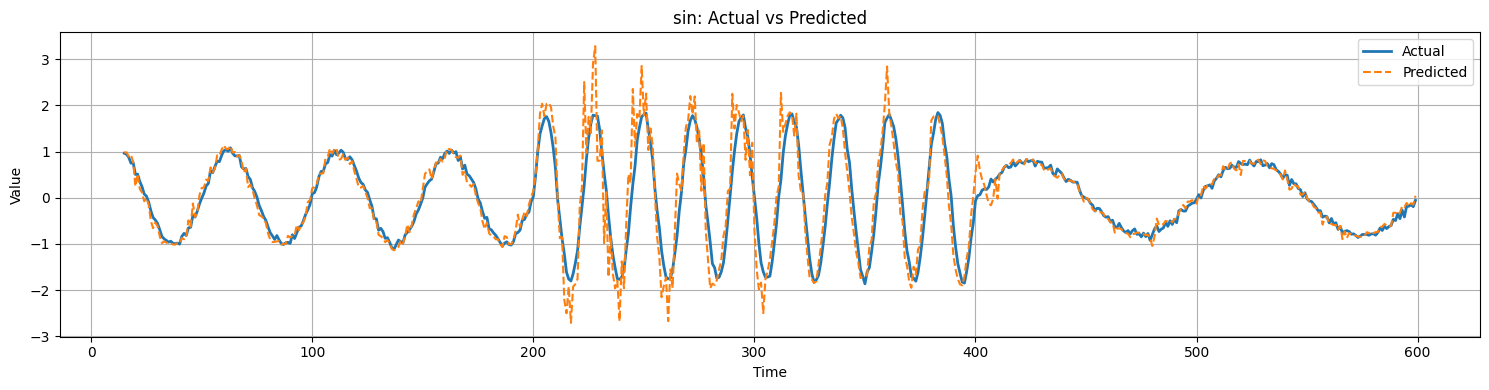

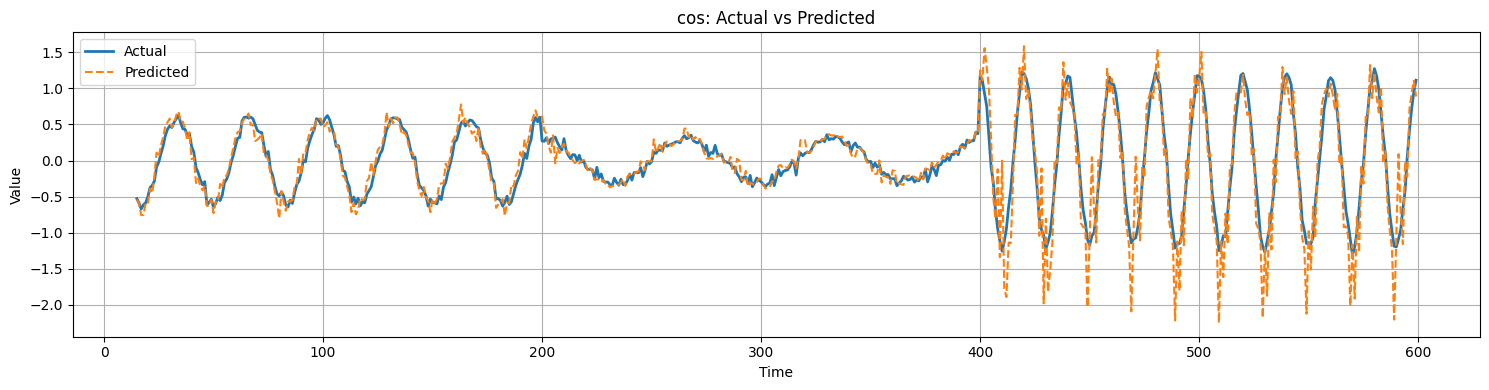

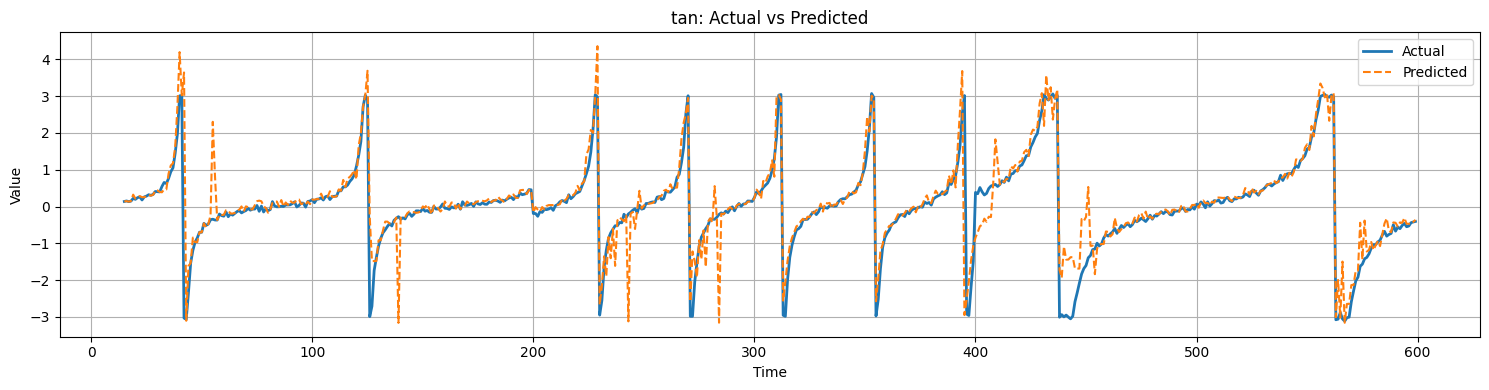

In [7]:
for var in columns:
    df_var = pd.DataFrame(results[var])
    if df_var.empty:
        print(f"No prediction data collected for {var}.")
        continue
    plot_actual_vs_predicted(df_var, variable_name=var)

## 6. Visualize global anomaly score and number of clusters

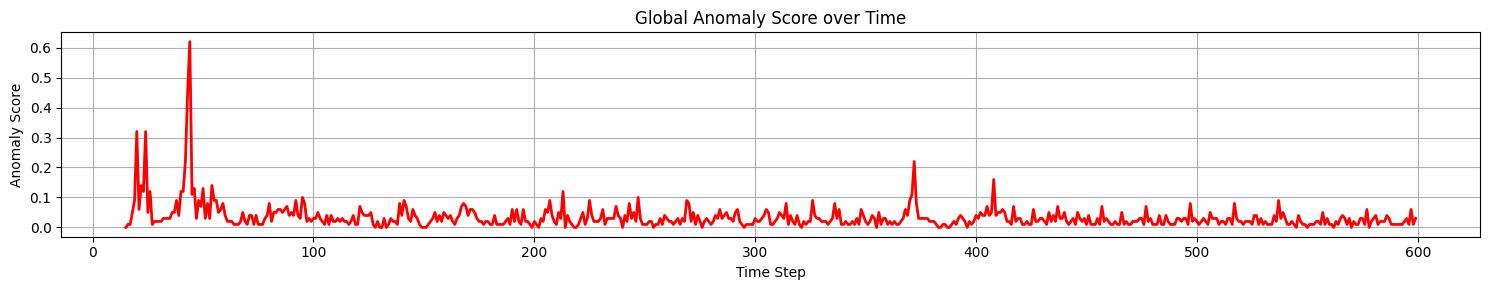

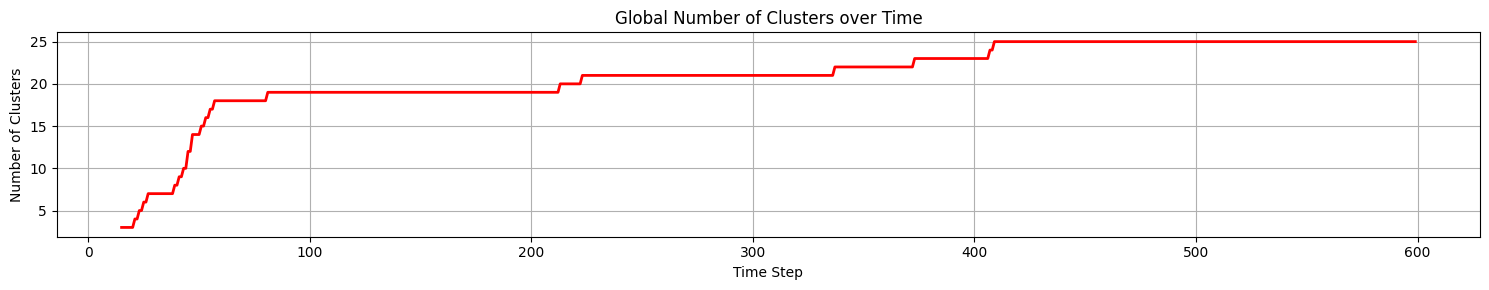

In [8]:
df_global = pd.DataFrame(global_results)

if df_global.empty:
    print("No global metrics collected.")
else:
    plot_time_series(
        df_global["timestamp"],
        df_global["anomaly_score"],
        title="Global Anomaly Score over Time",
        xlabel="Time Step",
        ylabel="Anomaly Score",
    )

    plot_time_series(
        df_global["timestamp"],
        df_global["number_of_clusters"],
        title="Global Number of Clusters over Time",
        xlabel="Time Step",
        ylabel="Number of Clusters",
    )

## 7. Inspect forecaster data stored on the server

In [9]:
show_forecaster_data(client, forecaster_id)

TARGETING URL 1: GET https://api.thingbook.io/access/api/driftmind/v1/forecasters/8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e/observations

=== Forecaster Data (total 16 points) ===
08-01-2026 19:38:16 → tan=-0.7785, sin=-0.7083, cos=0.3425
08-01-2026 19:38:46 → tan=-0.6745, sin=-0.6158, cos=0.0855
08-01-2026 19:39:16 → tan=-0.8046, sin=-0.6679, cos=-0.3673
08-01-2026 19:39:46 → tan=-0.7596, sin=-0.6221, cos=-0.7368
08-01-2026 19:40:16 → tan=-0.7311, sin=-0.6002, cos=-0.978
08-01-2026 19:40:46 → tan=-0.4958, sin=-0.4678, cos=-1.1872
08-01-2026 19:41:16 → tan=-0.6692, sin=-0.4928, cos=-1.1964
08-01-2026 19:41:46 → tan=-0.5595, sin=-0.3434, cos=-1.0853
08-01-2026 19:42:16 → tan=-0.6021, sin=-0.4527, cos=-0.9603
08-01-2026 19:42:46 → tan=-0.5144, sin=-0.2675, cos=-0.6649
08-01-2026 19:43:16 → tan=-0.4594, sin=-0.4163, cos=-0.42
08-01-2026 19:43:46 → tan=-0.5491, sin=-0.1866, cos=0.0555
08-01-2026 19:44:16 → tan=-0.5293, sin=-0.1839, cos=0.4216
08-01-2026 19:44:46 → tan=-0.4394, sin=-0.1503, cos=

## 8. List all the forecasters stored in the Server

In [10]:
import json 

all_forecasters = client.list_forecasters()

print(json.dumps(all_forecasters, indent=2))

TARGETING URL 1: GET https://api.thingbook.io/access/api/driftmind/v1
[
  {
    "object_id": "8e9b66ba-5ec0-41c5-901f-d7ccc2ed2c4e",
    "object_name": "Cold Start Demo",
    "created_at": "2026-01-08",
    "created_by": "8JBKROTrZ9CYSxFQ3e_e5uWhEOySOjkyMD0IzMDE3MTMwNjUwNTI4NzVcxNzU0NzMxMTM0ODY4Mjk2MjUw",
    "object_type": "FORECASTER",
    "data_processed": -0.42,
    "requests_processed": 1189
  },
  {
    "object_id": "1457379d-5c5e-446b-89e2-7b03803df72c",
    "object_name": "Cold Start Demo",
    "created_at": "2026-01-08",
    "created_by": "8JBKROTrZ9CYSxFQ3e_e5uWhEOySOjkyMD0IzMDE3MTMwNjUwNTI4NzVcxNzU0NzMxMTM0ODY4Mjk2MjUw",
    "object_type": "FORECASTER",
    "data_processed": -0.42,
    "requests_processed": 1187
  },
  {
    "object_id": "3290021a-5e08-483c-949b-56fba5935767",
    "object_name": "Cold Start Demo",
    "created_at": "2026-01-08",
    "created_by": "8JBKROTrZ9CYSxFQ3e_e5uWhEOySOjkyMD0IzMDE3MTMwNjUwNTI4NzVcxNzU0NzMxMTM0ODY4Mjk2MjUw",
    "object_type": "FORECAS